In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns = None
import warnings 

In [2]:
test = pd.read_csv('/kaggle/input/uspto-explainable-ai/test.csv')
test.head()

,publication_number,target_0,target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_11,target_12,target_13,target_14,target_15,target_16,target_17,target_18,target_19,target_20,target_21,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,target_31,target_32,target_33,target_34,target_35,target_36,target_37,target_38,target_39,target_40,target_41,target_42,target_43,target_44,target_45,target_46,target_47,target_48,target_49
0,US-2017082634-A1,US-2020225242-A1,US-2010137151-A1,US-10607721-B2,US-6747273-B2,US-6940065-B2,US-7684934-B2,US-2019018928-A1,US-9040903-B2,US-7847245-B2,US-8501421-B2,US-9110076-B2,US-10617717-B2,US-8741556-B2,US-9312110-B2,US-7865312-B2,US-11428696-B2,US-11646185-B2,US-7603240-B2,US-9879304-B2,US-9354236-B2,US-2022365028-A1,US-2014051105-A1,US-2021239708-A1,US-10825672-B2,US-2022397578-A1,US-9746477-B2,US-2022221467-A1,US-2016139140-A1,US-2019353660-A1,US-9110074-B2,US-8604692-B2,US-2017168055-A1,US-7499807-B1,US-2003008327-A1,US-2003166007-A1,US-10598642-B2,US-10401337-B2,US-2005221500-A1,US-2017023547-A1,US-2003157575-A1,US-10197576-B2,US-11011359-B2,US-7020559-B1,US-8642349-B1,US-2009253156-A1,US-7783429-B2,US-2003060983-A1,US-10914740-B2,US-7858389-B2,US-9747412-B2
1,US-2017180470-A1,US-2017171349-A1,US-2017171301-A1,US-2017155712-A1,US-2017163642-A1,US-2017155740-A1,US-2017180760-A1,US-2017155927-A1,US-2014289307-A1,US-9550119-B2,US-2017163478-A1,US-9280384-B2,US-2017155928-A1,US-2017163479-A1,US-10798147-B2,US-2017171150-A1,US-11582325-B2,US-11057489-B2,US-2017150214-A1,US-10182126-B2,US-9456024-B1,US-2017155695-A1,US-2017163706-A1,US-2021234919-A1,US-2014073370-A1,US-10075387-B1,US-2012005274-A1,US-8180857-B2,US-2017171566-A1,US-11432171-B2,US-2018227220-A1,US-10231269-B2,US-2017163761-A1,US-2017180468-A1,US-2022263759-A1,US-11582153-B2,US-2019245912-A1,US-2021389960-A1,US-2017171147-A1,US-10958580-B2,US-10897506-B2,US-11586626-B1,US-10945130-B2,US-2023041645-A1,US-2014310385-A1,US-9749174-B1,US-2014344473-A1,US-2017142196-A1,US-9276860-B2,US-2017149934-A1,US-2017153909-A1
2,US-2018029544-A1,US-9597956-B2,US-2015197150-A1,US-2015034146-A1,US-2012132245-A1,US-2014137939-A1,US-2011073163-A1,US-10916749-B2,US-9350288-B2,US-2020105953-A1,US-8875828-B2,US-9016765-B1,US-2017104446-A1,US-2014174506-A1,US-5741370-A,US-2012240982-A1,US-2011226335-A1,US-2011146761-A1,US-2011315191-A1,US-2021193855-A1,US-11394071-B2,US-10211355-B2,US-2012080074-A1,US-5762720-A,US-2015194924-A1,US-2019319145-A1,US-2012315528-A1,US-2012103401-A1,US-2022367940-A1,US-8952236-B2,US-11431044-B2,US-2016043257-A1,US-6631943-B2,US-2013000689-A1,US-2011155221-A1,US-2023011595-A1,US-9722116-B2,US-2013118556-A1,US-2014345833-A1,US-2019035962-A1,US-9278617-B2,US-8748737-B2,US-4717790-A,US-2022320600-A1,US-10784390-B2,US-11152660-B2,US-2022407163-A1,US-8056664-B2,US-2022140428-A1,US-2011100421-A1,US-9242554-B2
3,US-2022408153-A1,US-7698238-B2,US-10593167-B2,US-2013268955-A1,US-2022337693-A1,US-11416128-B2,US-2023031160-A1,US-10834456-B2,US-8898687-B2,US-2020301398-A1,US-7610260-B2,US-2018018899-A1,US-2022020053-A1,US-2012004575-A1,US-11412178-B2,US-2022021682-A1,US-10960173-B2,US-9542567-B2,US-10225608-B2,US-11538454-B2,US-2015070516-A1,US-11671657-B2,US-2015081304-A1,US-2014337868-A1,US-9706235-B2,US-9894415-B2,US-2007271580-A1,US-10083363-B2,US-8634701-B2,US-10798438-B2,US-2022368770-A1,US-2015243083-A1,US-2021256046-A1,US-10368112-B2,US-10015385-B2,US-2014351720-A1,US-2014325540-A1,US-2023087729-A1,US-2019339771-A1,US-2019019336-A1,US-8704760-B2,US-11205426-B2,US-10466955-B1,US-11483618-B2,US-2020275875-A1,US-2015150032-A1,US-2022070066-A1,US-2022038510-A1,US-11057728-B2,US-2022391011-A1,US-10877555-B2
4,US-2268569-A,US-2332522-A,US-2268570-A,US-2407088-A,US-2581437-A,US-1972352-A,US-2201671-A,US-2625280-A,US-2319257-A,US-2770378-A,US-2593693-A,US-2365773-A,US-2231484-A,US-2585095-A,US-2676717-A,US-2592457-A,US-2406826-A,US-2070415-A,US-1514008-A,US-22493

In [3]:
train = pd.read_csv('/kaggle/input/uspto-explainable-ai/sample_submission.csv')
train.head()  

,publication_number,query
0,US-2017082634-A1,text AND search
1,US-2017180470-A1,text AND search
2,US-2018029544-A1,text AND search
3,US-2022408153-A1,text AND search
4,US-2268569-A,text AND search


In [4]:
combined = pd.concat([test,train])
combined.head()

,publication_number,target_0,target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,target_9,target_10,target_11,target_12,target_13,target_14,target_15,target_16,target_17,target_18,target_19,target_20,target_21,target_22,target_23,target_24,target_25,target_26,target_27,target_28,target_29,target_30,target_31,target_32,target_33,target_34,target_35,target_36,target_37,target_38,target_39,target_40,target_41,target_42,target_43,target_44,target_45,target_46,target_47,target_48,target_49,query
0,US-2017082634-A1,US-2020225242-A1,US-2010137151-A1,US-10607721-B2,US-6747273-B2,US-6940065-B2,US-7684934-B2,US-2019018928-A1,US-9040903-B2,US-7847245-B2,US-8501421-B2,US-9110076-B2,US-10617717-B2,US-8741556-B2,US-9312110-B2,US-7865312-B2,US-11428696-B2,US-11646185-B2,US-7603240-B2,US-9879304-B2,US-9354236-B2,US-2022365028-A1,US-2014051105-A1,US-2021239708-A1,US-10825672-B2,US-2022397578-A1,US-9746477-B2,US-2022221467-A1,US-2016139140-A1,US-2019353660-A1,US-9110074-B2,US-8604692-B2,US-2017168055-A1,US-7499807-B1,US-2003008327-A1,US-2003166007-A1,US-10598642-B2,US-10401337-B2,US-2005221500-A1,US-2017023547-A1,US-2003157575-A1,US-10197576-B2,US-11011359-B2,US-7020559-B1,US-8642349-B1,US-2009253156-A1,US-7783429-B2,US-2003060983-A1,US-10914740-B2,US-7858389-B2,US-9747412-B2,NaN
1,US-2017180470-A1,US-2017171349-A1,US-2017171301-A1,US-2017155712-A1,US-2017163642-A1,US-2017155740-A1,US-2017180760-A1,US-2017155927-A1,US-2014289307-A1,US-9550119-B2,US-2017163478-A1,US-9280384-B2,US-2017155928-A1,US-2017163479-A1,US-10798147-B2,US-2017171150-A1,US-11582325-B2,US-11057489-B2,US-2017150214-A1,US-10182126-B2,US-9456024-B1,US-2017155695-A1,US-2017163706-A1,US-2021234919-A1,US-2014073370-A1,US-10075387-B1,US-2012005274-A1,US-8180857-B2,US-2017171566-A1,US-11432171-B2,US-2018227220-A1,US-10231269-B2,US-2017163761-A1,US-2017180468-A1,US-2022263759-A1,US-11582153-B2,US-2019245912-A1,US-2021389960-A1,US-2017171147-A1,US-10958580-B2,US-10897506-B2,US-11586626-B1,US-10945130-B2,US-2023041645-A1,US-2014310385-A1,US-9749174-B1,US-2014344473-A1,US-2017142196-A1,US-9276860-B2,US-2017149934-A1,US-2017153909-A1,NaN
2,US-2018029544-A1,US-9597956-B2,US-2015197150-A1,US-2015034146-A1,US-2012132245-A1,US-2014137939-A1,US-2011073163-A1,US-10916749-B2,US-9350288-B2,US-2020105953-A1,US-8875828-B2,US-9016765-B1,US-2017104446-A1,US-2014174506-A1,US-5741370-A,US-2012240982-A1,US-2011226335-A1,US-2011146761-A1,US-2011315191-A1,US-2021193855-A1,US-11394071-B2,US-10211355-B2,US-2012080074-A1,US-5762720-A,US-2015194924-A1,US-2019319145-A1,US-2012315528-A1,US-2012103401-A1,US-2022367940-A1,US-8952236-B2,US-11431044-B2,US-2016043257-A1,US-6631943-B2,US-2013000689-A1,US-2011155221-A1,US-2023011595-A1,US-9722116-B2,US-2013118556-A1,US-2014345833-A1,US-2019035962-A1,US-9278617-B2,US-8748737-B2,US-4717790-A,US-2022320600-A1,US-10784390-B2,US-11152660-B2,US-2022407163-A1,US-8056664-B2,US-2022140428-A1,US-2011100421-A1,US-9242554-B2,NaN
3,US-2022408153-A1,US-7698238-B2,US-10593167-B2,US-2013268955-A1,US-2022337693-A1,US-11416128-B2,US-2023031160-A1,US-10834456-B2,US-8898687-B2,US-2020301398-A1,US-7610260-B2,US-2018018899-A1,US-2022020053-A1,US-2012004575-A1,US-11412178-B2,US-2022021682-A1,US-10960173-B2,US-9542567-B2,US-10225608-B2,US-11538454-B2,US-2015070516-A1,US-11671657-B2,US-2015081304-A1,US-2014337868-A1,US-9706235-B2,US-9894415-B2,US-2007271580-A1,US-10083363-B2,US-8634701-B2,US-10798438-B2,US-2022368770-A1,US-2015243083-A1,US-2021256046-A1,US-10368112-B2,US-10015385-B2,US-2014351720-A1,US-2014325540-A1,US-2023087729-A1,US-2019339771-A1,US-2019019336-A1,US-8704760-B2,US-11205426-B2,US-10466955-B1,US-11483618-B2,US-2020275875-A1,US-2015150032-A1,US-2022070066-A1,US-2022038510-A1,US-11057728-B2,US-2022391011-A1,US-10877555-B2,NaN
4,US-2268569-A,US-2332522-A,US-2268570-A,US-2407088-A,US-2581437-A,US-1972352-A,US-2201671-A,US-2625280-A,US-2319257-A,US-2770378-A,US-2593693-A,US-2365773-A,US-2231484-A,US-2585095-A,US-2676717-A,US-2592457-A,US-2406826-A,US-2070415-A

In [11]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 0 to 9
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   publication_number  20 non-null     object
 1   target_0            10 non-null     object
 2   target_1            10 non-null     object
 3   target_2            10 non-null     object
 4   target_3            10 non-null     object
 5   target_4            10 non-null     object
 6   target_5            10 non-null     object
 7   target_6            10 non-null     object
 8   target_7            10 non-null     object
 9   target_8            10 non-null     object
 10  target_9            10 non-null     object
 11  target_10           10 non-null     object
 12  target_11           10 non-null     object
 13  target_12           10 non-null     object
 14  target_13           10 non-null     object
 15  target_14           10 non-null     object
 16  target_15           10 non-null   

In [24]:
combined.dtypes

publication_number    object
target_0              object
target_1              object
target_2              object
target_3              object
target_4              object
target_5              object
target_6              object
target_7              object
target_8              object
target_9              object
target_10             object
target_11             object
target_12             object
target_13             object
target_14             object
target_15             object
target_16             object
target_17             object
target_18             object
target_19             object
target_20             object
target_21             object
target_22             object
target_23             object
target_24             object
target_25             object
target_26             object
target_27             object
target_28             object
target_29             object
target_30             object
target_31             object
target_32             object
target_33     

In [26]:
combined.columns

Index(['publication_number', 'target_0', 'target_1', 'target_2', 'target_3',
       'target_4', 'target_5', 'target_6', 'target_7', 'target_8', 'target_9',
       'target_10', 'target_11', 'target_12', 'target_13', 'target_14',
       'target_15', 'target_16', 'target_17', 'target_18', 'target_19',
       'target_20', 'target_21', 'target_22', 'target_23', 'target_24',
       'target_25', 'target_26', 'target_27', 'target_28', 'target_29',
       'target_30', 'target_31', 'target_32', 'target_33', 'target_34',
       'target_35', 'target_36', 'target_37', 'target_38', 'target_39',
       'target_40', 'target_41', 'target_42', 'target_43', 'target_44',
       'target_45', 'target_46', 'target_47', 'target_48', 'target_49',
       'query'],
      dtype='object')

In [27]:
combined.describe().T

,count,unique,top,freq
publication_number,20,10,US-2017082634-A1,2
target_0,10,10,US-2020225242-A1,1
target_1,10,10,US-2010137151-A1,1
target_2,10,10,US-10607721-B2,1
target_3,10,10,US-6747273-B2,1
target_4,10,10,US-6940065-B2,1
target_5,10,10,US-7684934-B2,1
target_6,10,10,US-2019018928-A1,1
target_7,10,10,US-9040903-B2,1
target_8,10,10,US-7847245-B2,1


In [29]:
combined.corr

<bound method DataFrame.corr of   publication_number          target_0          target_1          target_2  \
0   US-2017082634-A1  US-2020225242-A1  US-2010137151-A1    US-10607721-B2   
1   US-2017180470-A1  US-2017171349-A1  US-2017171301-A1  US-2017155712-A1   
2   US-2018029544-A1     US-9597956-B2  US-2015197150-A1  US-2015034146-A1   
3   US-2022408153-A1     US-7698238-B2    US-10593167-B2  US-2013268955-A1   
4       US-2268569-A      US-2332522-A      US-2268570-A      US-2407088-A   
5       US-3371854-A      US-3371853-A      US-3428241-A      US-2888189-A   
6       US-3589189-A      US-5415032-A      US-3415121-A      US-1886364-A   
7       US-3881203-A      US-2777179-A      US-3898717-A      US-2453507-A   
8       US-4845770-A      US-3177470-A      US-3627991-A      US-5301243-A   
9        US-695233-A       US-737196-A       US-609673-A       US-635029-A   
0   US-2017082634-A1               NaN               NaN               NaN   
1   US-2017180470-A1            

In [30]:
combined.sha

(20, 52)

In [5]:
combined.skew

<bound method DataFrame.skew of   publication_number          target_0          target_1          target_2  \
0   US-2017082634-A1  US-2020225242-A1  US-2010137151-A1    US-10607721-B2   
1   US-2017180470-A1  US-2017171349-A1  US-2017171301-A1  US-2017155712-A1   
2   US-2018029544-A1     US-9597956-B2  US-2015197150-A1  US-2015034146-A1   
3   US-2022408153-A1     US-7698238-B2    US-10593167-B2  US-2013268955-A1   
4       US-2268569-A      US-2332522-A      US-2268570-A      US-2407088-A   
5       US-3371854-A      US-3371853-A      US-3428241-A      US-2888189-A   
6       US-3589189-A      US-5415032-A      US-3415121-A      US-1886364-A   
7       US-3881203-A      US-2777179-A      US-3898717-A      US-2453507-A   
8       US-4845770-A      US-3177470-A      US-3627991-A      US-5301243-A   
9        US-695233-A       US-737196-A       US-609673-A       US-635029-A   
0   US-2017082634-A1               NaN               NaN               NaN   
1   US-2017180470-A1            

In [6]:
combined.kurt

<bound method DataFrame.kurt of   publication_number          target_0          target_1          target_2  \
0   US-2017082634-A1  US-2020225242-A1  US-2010137151-A1    US-10607721-B2   
1   US-2017180470-A1  US-2017171349-A1  US-2017171301-A1  US-2017155712-A1   
2   US-2018029544-A1     US-9597956-B2  US-2015197150-A1  US-2015034146-A1   
3   US-2022408153-A1     US-7698238-B2    US-10593167-B2  US-2013268955-A1   
4       US-2268569-A      US-2332522-A      US-2268570-A      US-2407088-A   
5       US-3371854-A      US-3371853-A      US-3428241-A      US-2888189-A   
6       US-3589189-A      US-5415032-A      US-3415121-A      US-1886364-A   
7       US-3881203-A      US-2777179-A      US-3898717-A      US-2453507-A   
8       US-4845770-A      US-3177470-A      US-3627991-A      US-5301243-A   
9        US-695233-A       US-737196-A       US-609673-A       US-635029-A   
0   US-2017082634-A1               NaN               NaN               NaN   
1   US-2017180470-A1            

<Axes: >

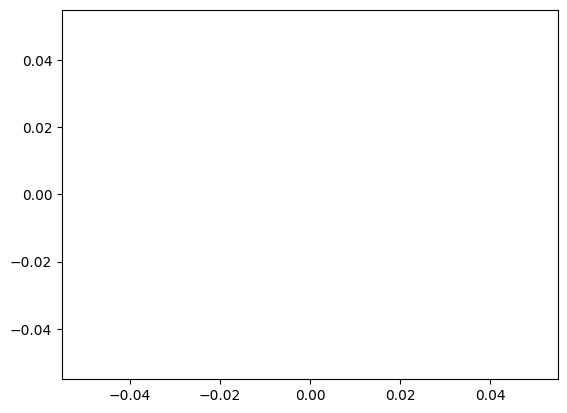

In [10]:
sns.scatterplot(combined)

In [14]:
cat_cols = combined.select_dtypes(include='object')

In [15]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print('\n')
    print(''*50)

publication_number



target_0



target_1



target_2



target_3



target_4



target_5



target_6



target_7



target_8



target_9



target_10



target_11



target_12



target_13



target_14



target_15



target_16



target_17



target_18



target_19



target_20



target_21



target_22



target_23



target_24



target_25



target_26



target_27



target_28



target_29



target_30



target_31



target_32



target_33



target_34



target_35



target_36



target_37



target_38



target_39



target_40



target_41



target_42



target_43



target_44



target_45



target_46



target_47



target_48



target_49



query





In [26]:
num_cols = combined.select_dtypes(include='number')

In [27]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('\n')
    print(''*50)

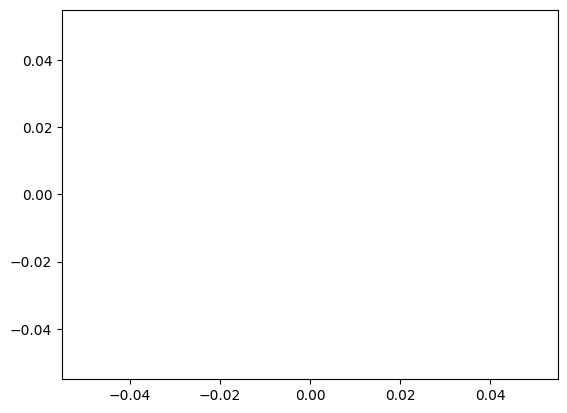

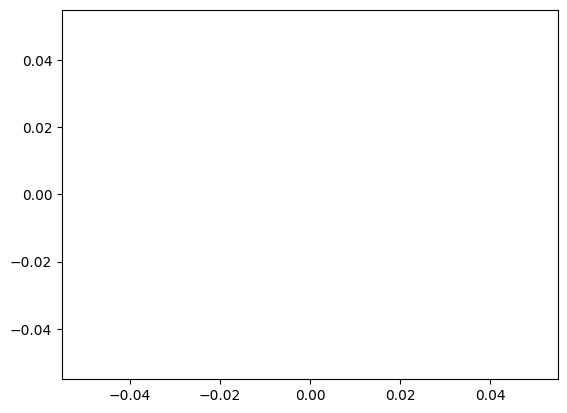

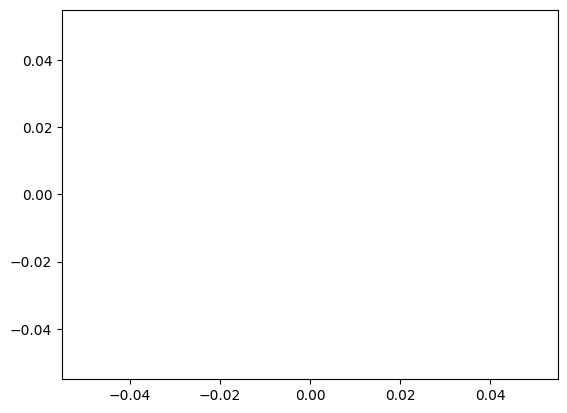

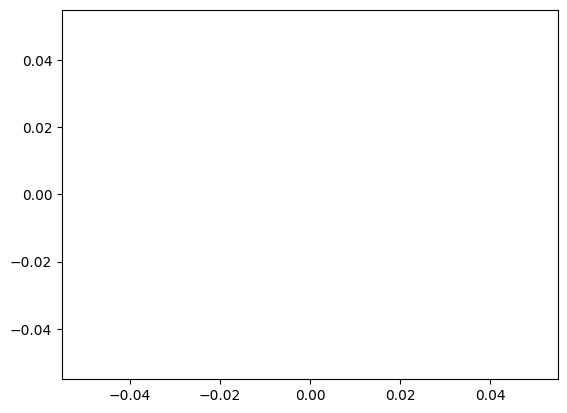

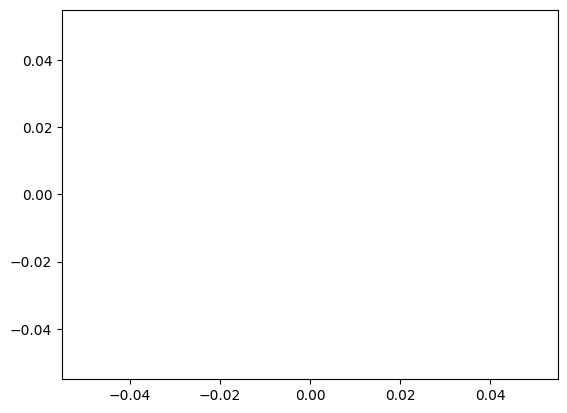

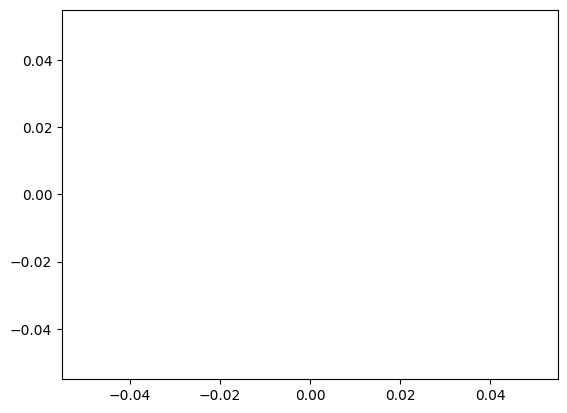

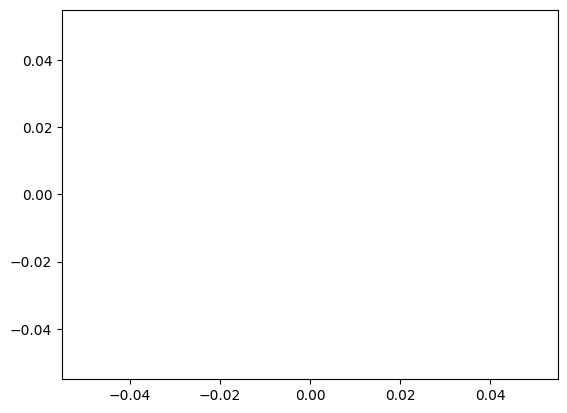

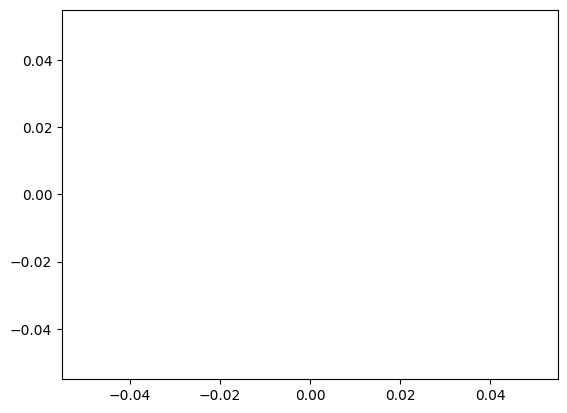

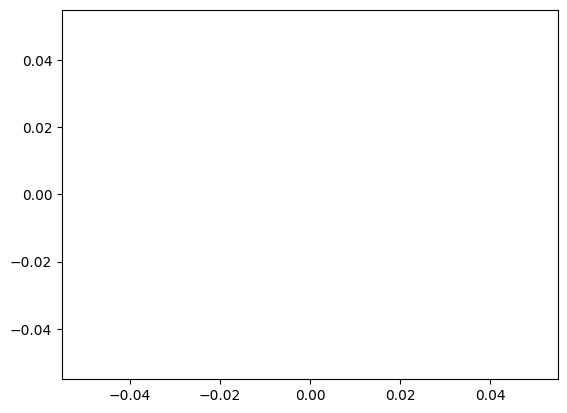

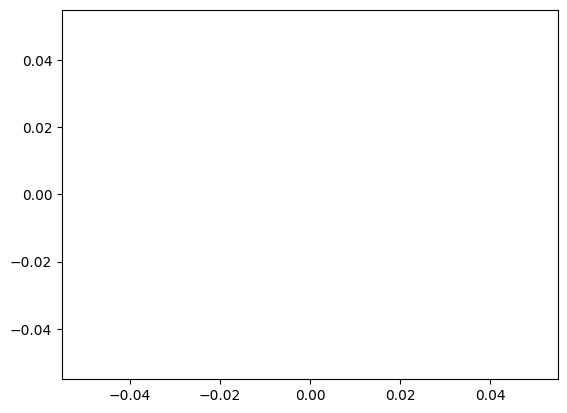

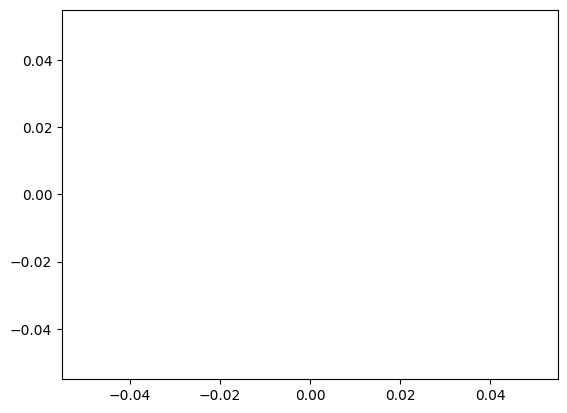

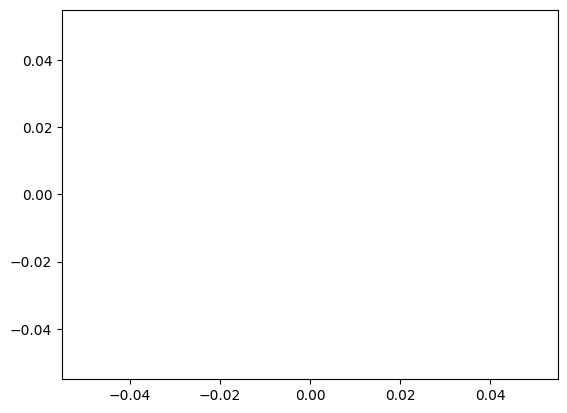

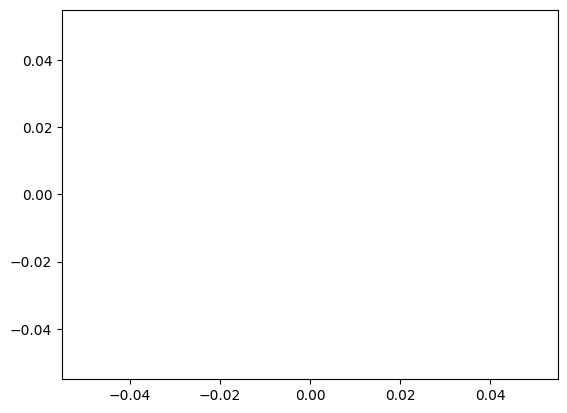

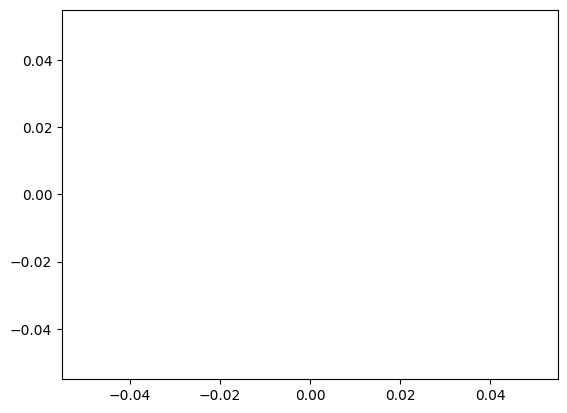

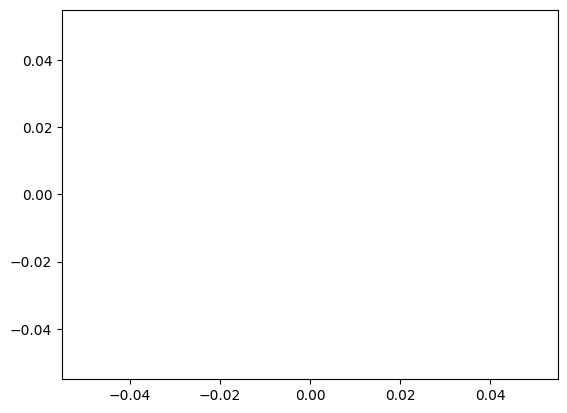

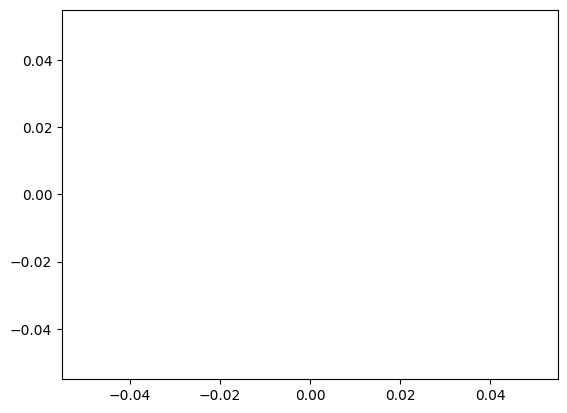

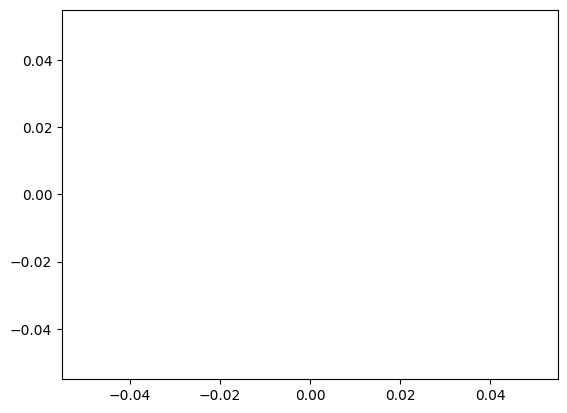

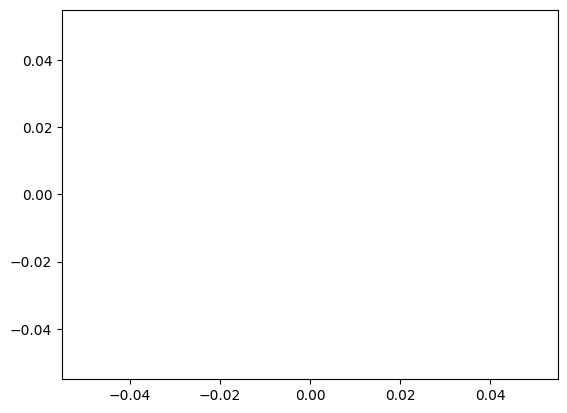

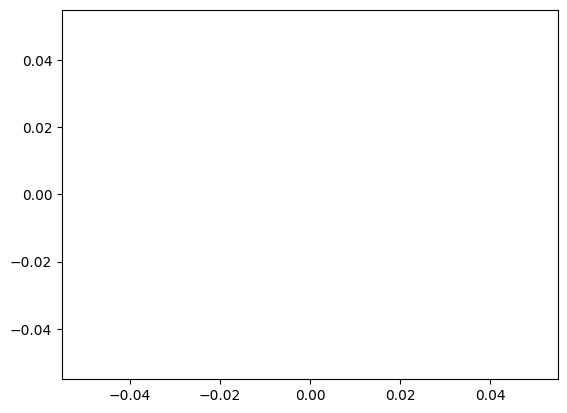

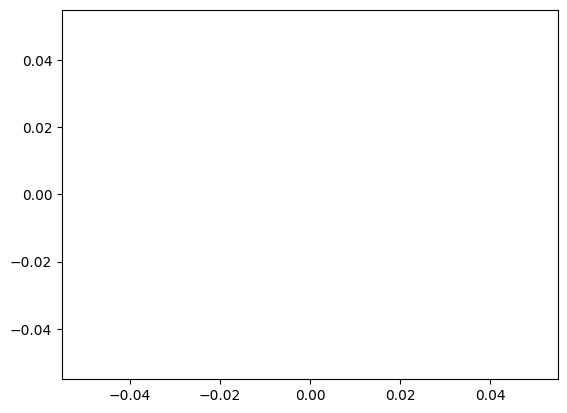

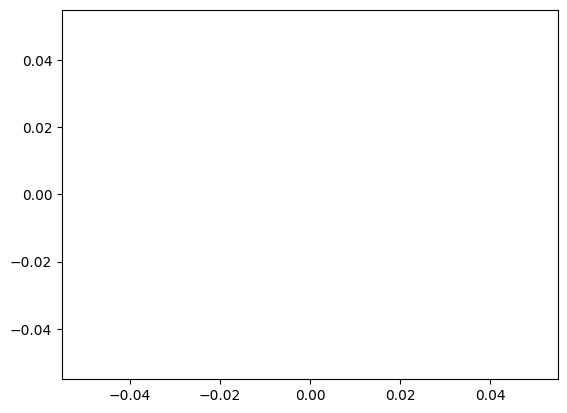

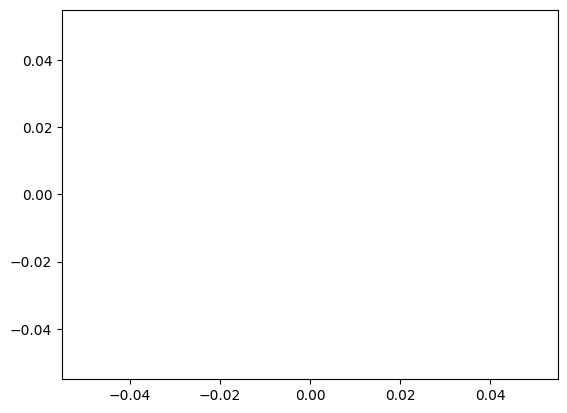

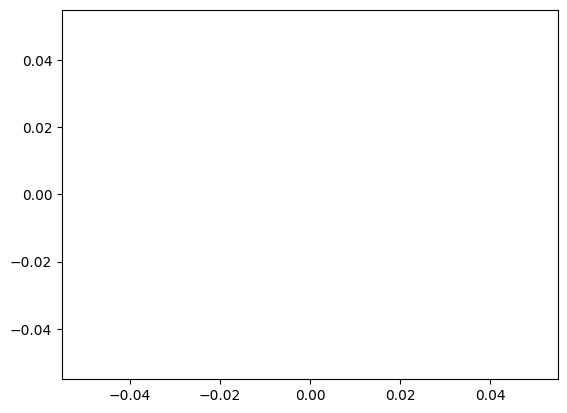

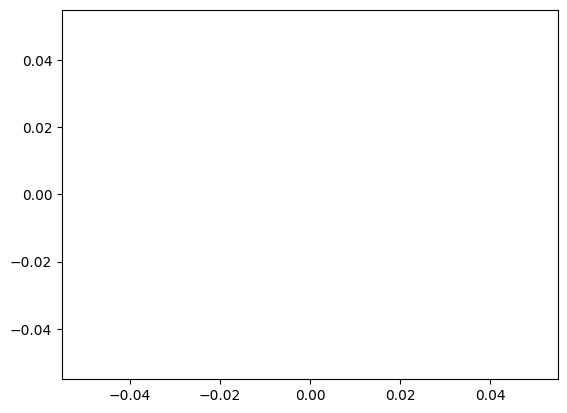

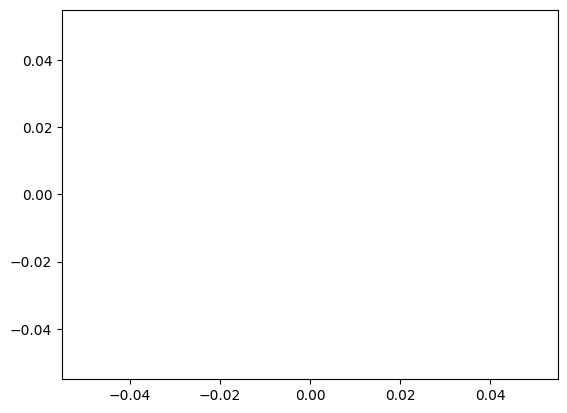

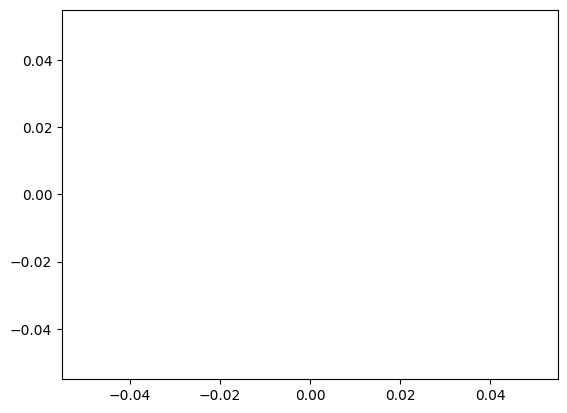

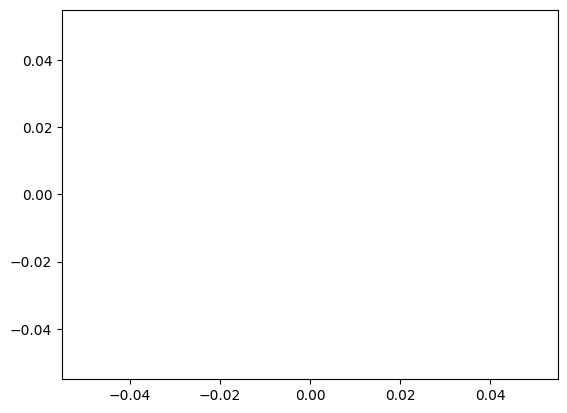

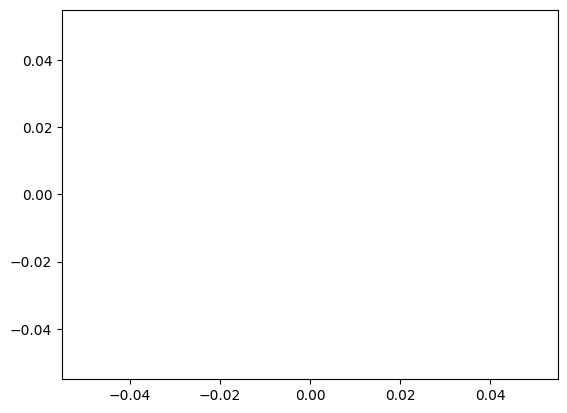

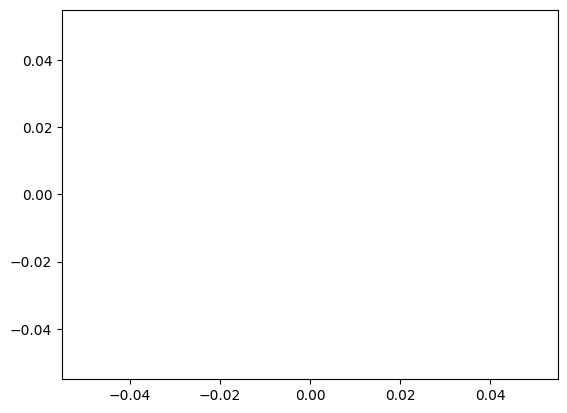

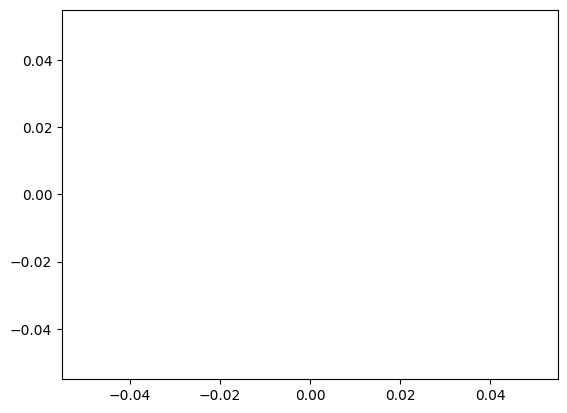

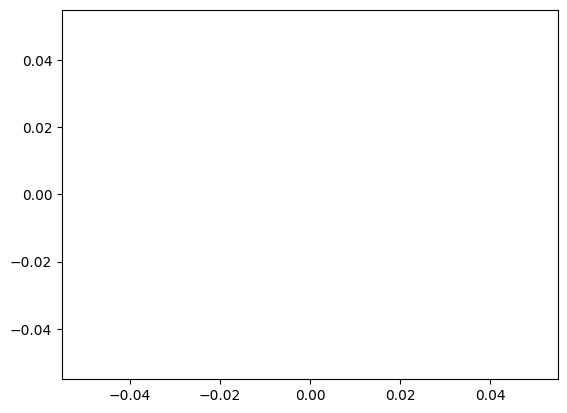

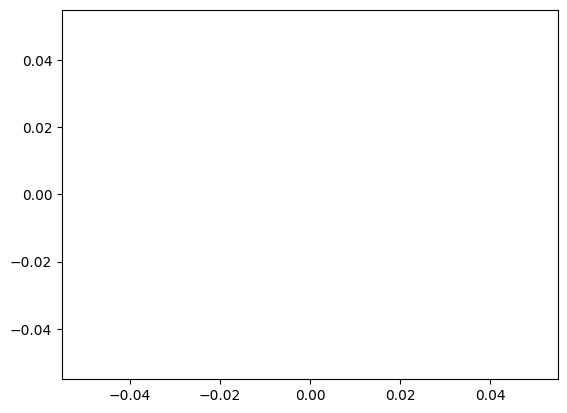

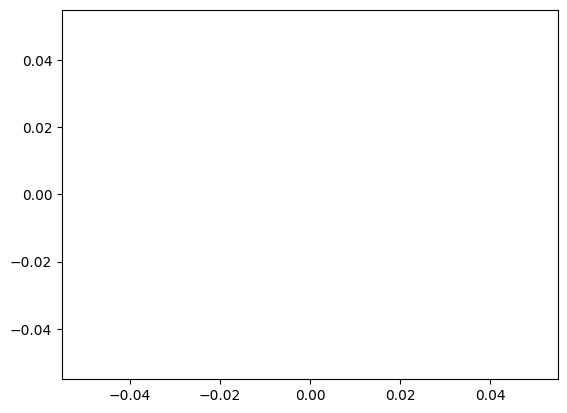

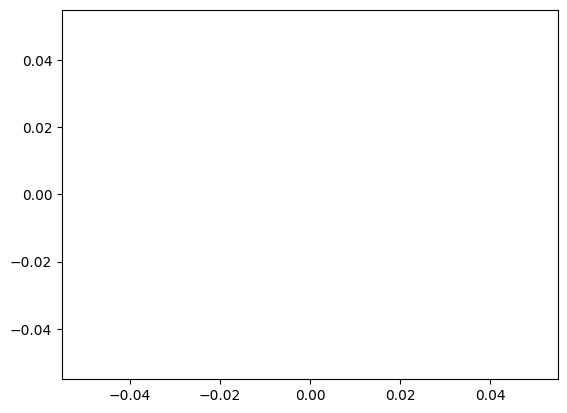

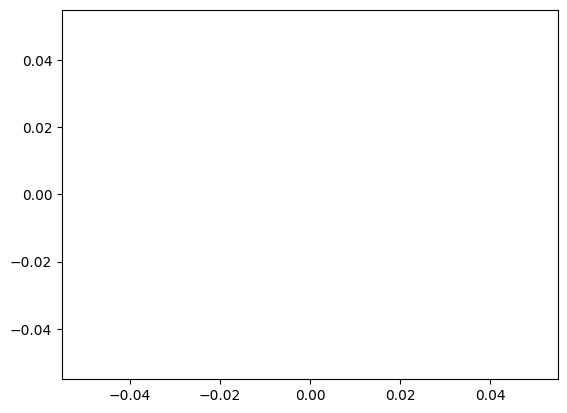

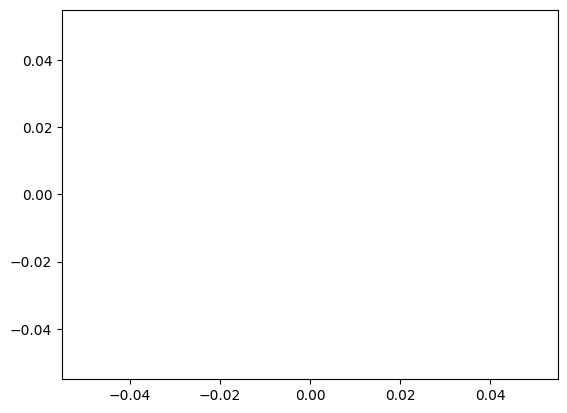

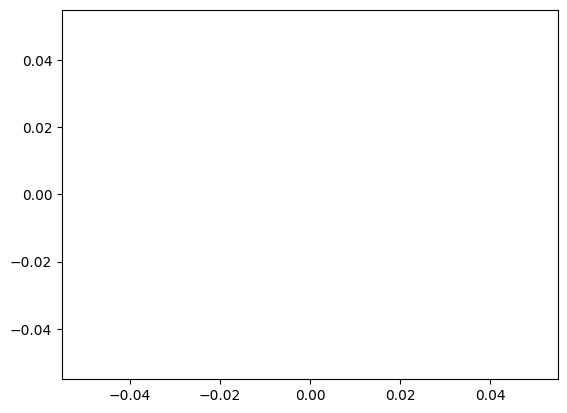

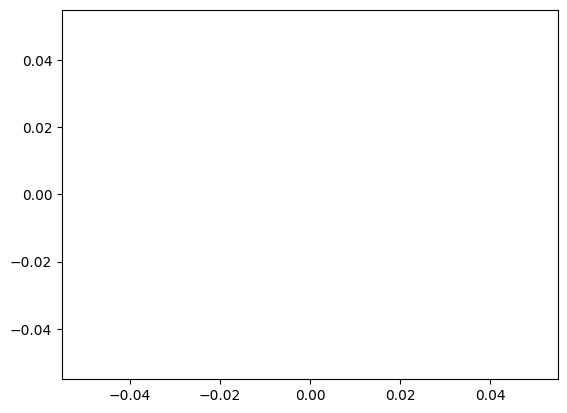

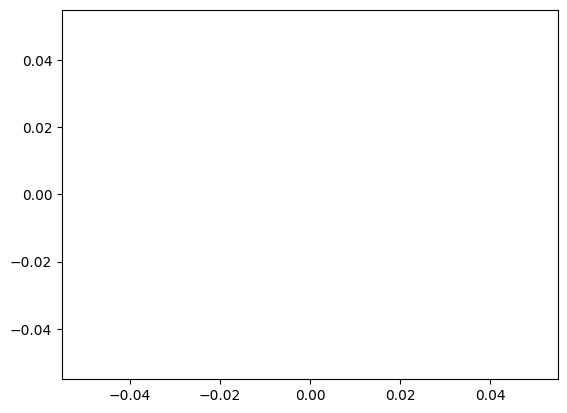

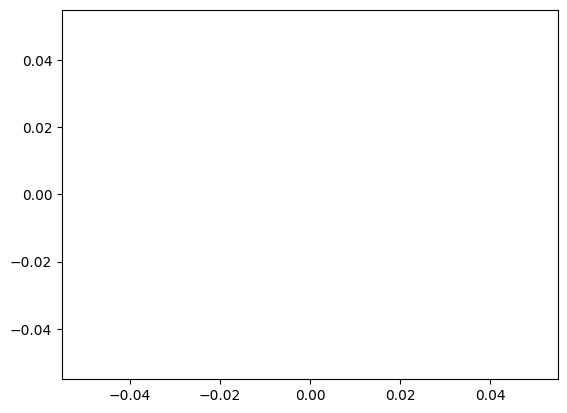

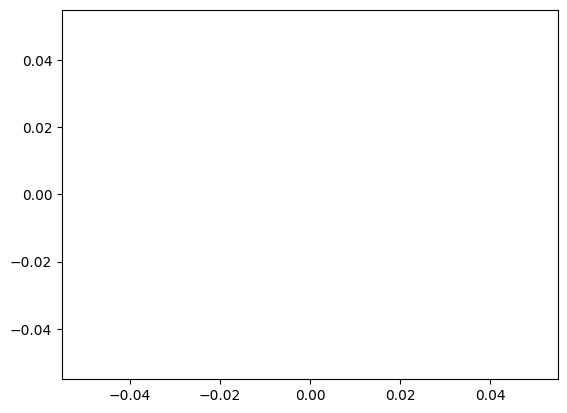

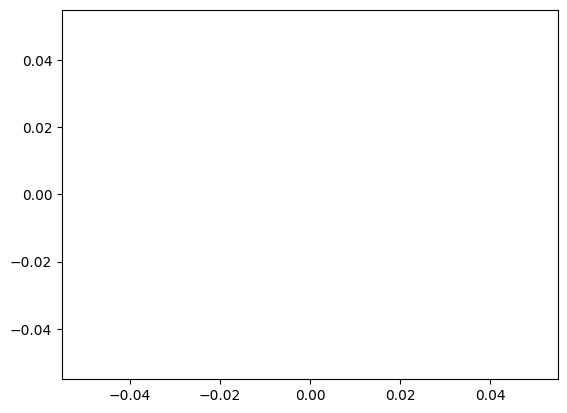

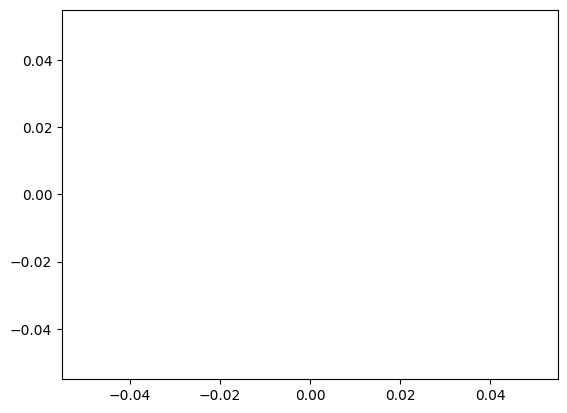

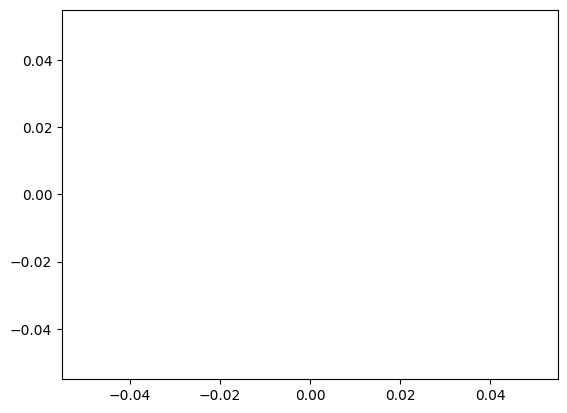

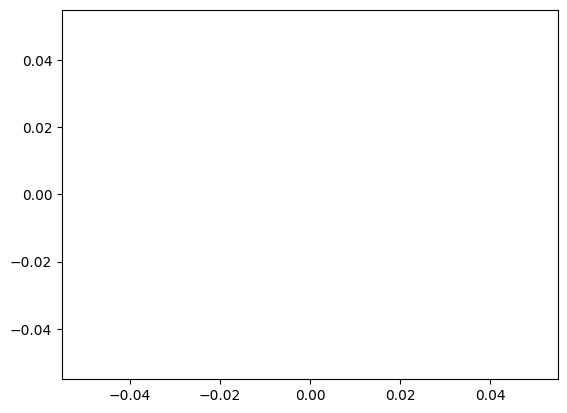

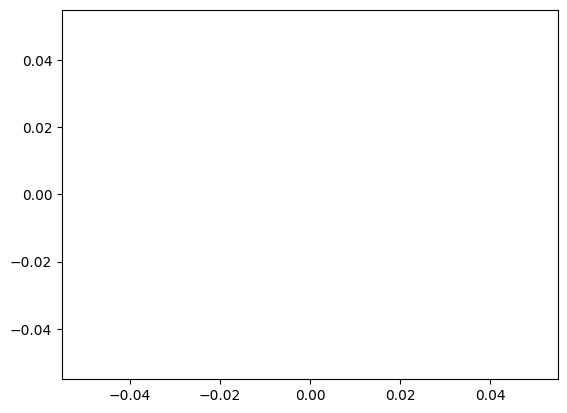

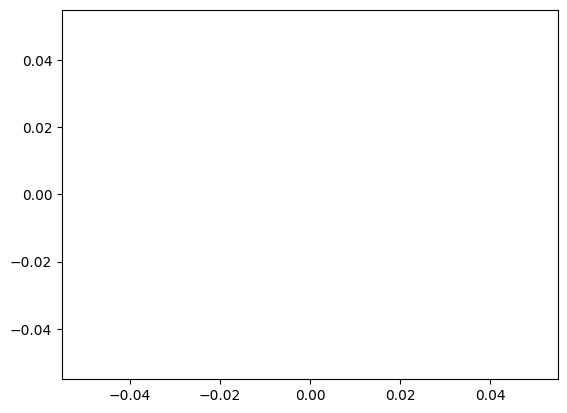

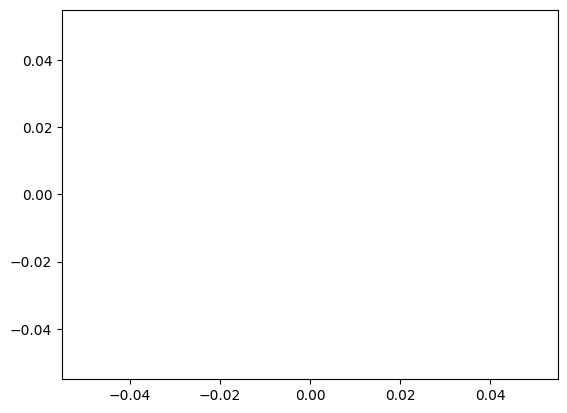

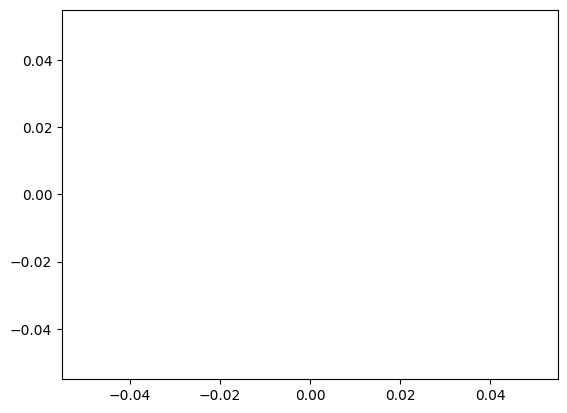

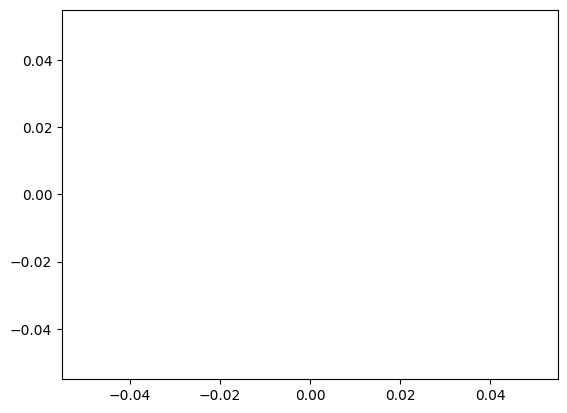

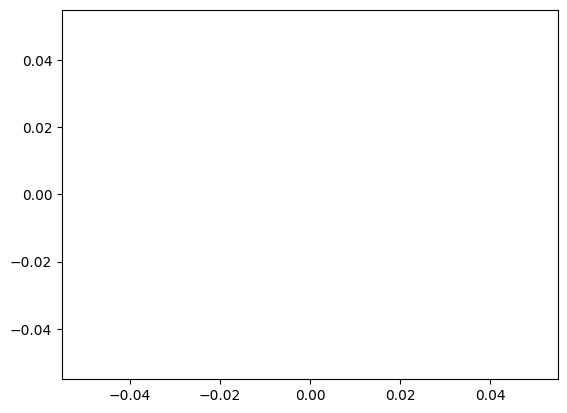

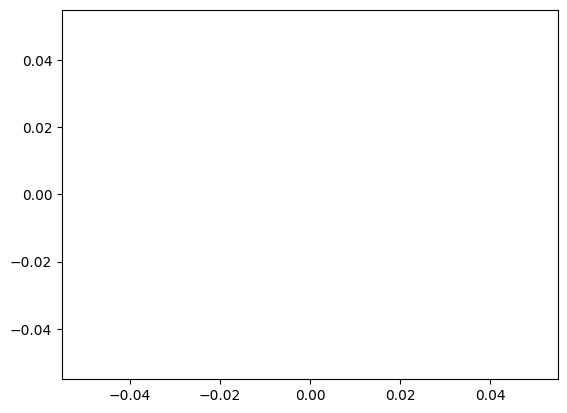

In [32]:
x = 1
cat_cols = combined.select_dtypes(include='object')
for i in cat_cols:
    sns.scatterplot(data=combined)
    print('\n')
    plt.show()